In [1]:
import os
import sys

# sys.path.append(os.path.join("/srv/sferraro/choreographer/"))
os.environ["MUJOCO_GL"] = "egl"

from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

# from custom_robosuite_tasks import *

cameras = ["agentview", "frontview"]
size=(64,64)

env = CustomLift(
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names=cameras,
                camera_depths=True,
                # render_visual_mesh=False,
                cube_minsize=(0.04, 0.04, 0.04),
                camera_segmentations="element",
                camera_heights= size[0],  # image h|eight
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [2]:
# move camera to agentview2 

cam_mover = CM(env, camera=cameras[0])
(start_cam_pos, start_cam_quat) = cam_mover.get_camera_pose()
start_cam_pos += [0.2, 0.0, 0.5]

cam_mover.set_camera_pose(pos=start_cam_pos)

In [3]:
action = [0,0,0,0,0,0,0,0]
env_state, rew, done, info = env.step(action)

init_qpos = [-0.3, 0.85, 0, -2.2, 0, 3, 0.75]
env.robots[0].set_robot_joint_positions(init_qpos)
env.robots[0].controller.update_initial_joints(init_qpos)
env.robots[0].controller.reset_goal()

env_state = env._get_observations(force_update=True)

def state_extraction(cameras, env_state):

    rgb = {}
    depth = {}
    seg = {}
    
    for camera in cameras:
        rgb[camera] = env_state[camera + "_image"][::-1].transpose(2, 0, 1)
        depth[camera] = env_state[camera + "_depth"][::-1].transpose(2, 0, 1)

        # obtain world coordinates from the segmentation mask
        # depth_map = CU.get_real_depth_map(sim=self._env.sim, depth_map=depth)

        seg[camera] = env_state[
            camera + "_segmentation_" + "element"
        ][::-1].transpose(2, 0, 1)

    return  rgb, depth, seg

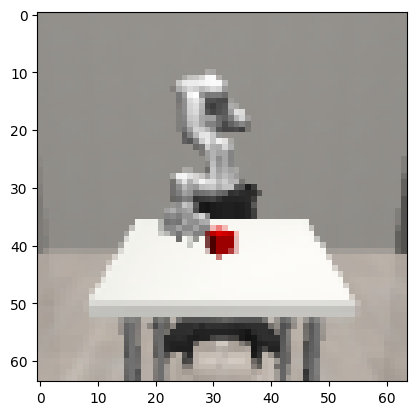

In [6]:
import matplotlib.pyplot as plt

rgb, depth, seg = state_extraction(cameras, env_state)

id = 1

plt.imshow(rgb[cameras[id]].transpose(1,2,0))

from PIL import Image
im = Image.fromarray(rgb[cameras[id]].transpose(1,2,0))
im.save("panda.png")

In [7]:
import voxel

/home/elephant/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
